# 03 — Algoritmos Genéticos: ubicación de hospitales

**Curso:** Inteligencia Artificial — Optimización

Usaremos el mismo problema de Hill Climbing y Simulated Annealing:

> Ubicar varios hospitales en una cuadrícula para minimizar la distancia total de las casas al hospital más cercano.

## Objetivos

- representar una solución mediante un cromosoma;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- comparar el mejor individuo y el fitness medio.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

## 1. Problema

Para cada casa $h$, calculamos su distancia al hospital más cercano:

$$
C(H)=
\sum_{h\in\text{casas}}
\min_{p\in H}
d_{\text{Manhattan}}(h,p)
$$

Queremos minimizar $C(H)$.

Como los algoritmos genéticos suelen expresarse como maximización, definimos:

$$
\text{fitness}(H)=-C(H)
$$

Por tanto, un fitness mayor representa una solución de menor costo.

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def fitness(individual, houses):
    return -total_cost(houses, individual)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

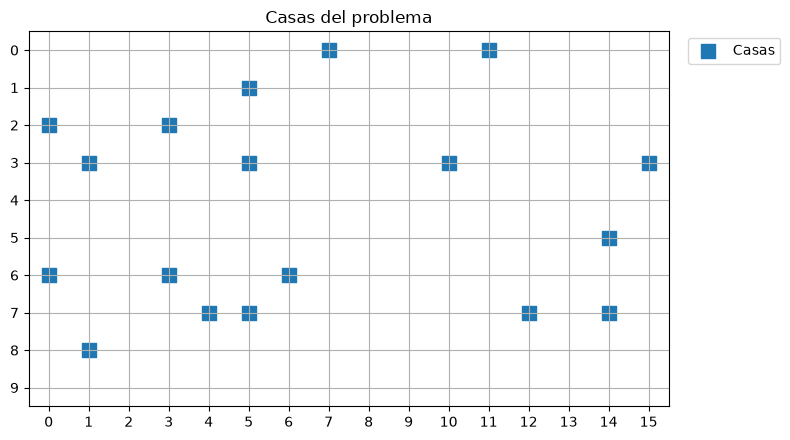

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

rng = random.Random(SEED)

houses = set(rng.sample(all_cells, NUM_HOUSES))
valid_hospital_cells = [
    cell for cell in all_cells
    if cell not in houses
]

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hospitals=[],
    title="Casas del problema",
)

## 2. Representación del cromosoma

Cada individuo contiene las posiciones de los hospitales:

```python
[(fila_1, columna_1), (fila_2, columna_2), (fila_3, columna_3)]
```

Restricciones de la representación:

- ningún hospital puede ubicarse sobre una casa;
- dos hospitales no pueden ocupar la misma celda.

Individuo: [(3, 8), (7, 6), (1, 9)]
Costo: 87
Fitness: -87


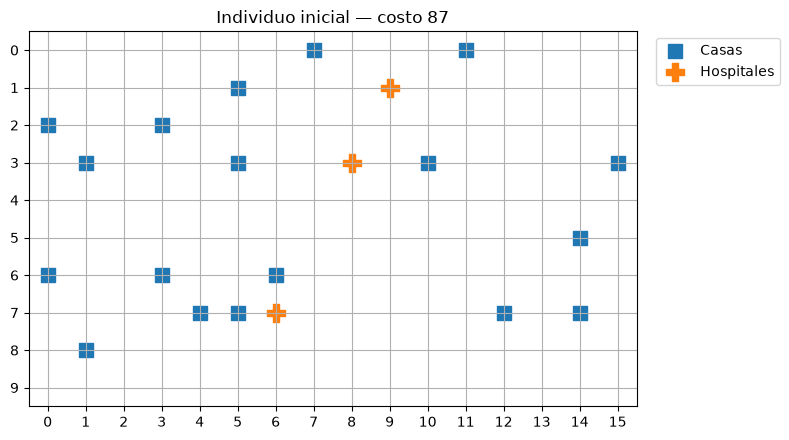

In [4]:
def create_individual(valid_cells, num_hospitals, rng):
    return rng.sample(valid_cells, num_hospitals)


example = create_individual(
    valid_hospital_cells,
    NUM_HOSPITALS,
    rng,
)

print("Individuo:", example)
print("Costo:", total_cost(houses, example))
print("Fitness:", fitness(example, houses))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    example,
    title=f"Individuo inicial — costo {total_cost(houses, example)}",
)

## 3. Población inicial

Un algoritmo genético no mantiene una única solución, sino una población de soluciones candidatas.

In [5]:
def create_population(
    population_size,
    valid_cells,
    num_hospitals,
    rng,
):
    return [
        create_individual(valid_cells, num_hospitals, rng)
        for _ in range(population_size)
    ]


population = create_population(
    population_size=10,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

for i, individual in enumerate(population[:5]):
    print(
        f"{i}: {individual} | "
        f"costo={total_cost(houses, individual)}"
    )

0: [(8, 14), (4, 4), (0, 5)] | costo=71
1: [(4, 13), (9, 7), (7, 7)] | costo=102
2: [(8, 11), (6, 14), (2, 1)] | costo=83
3: [(4, 11), (1, 11), (1, 2)] | costo=88
4: [(6, 15), (6, 13), (1, 14)] | costo=152


## 4. Selección por torneo

Se toman varios individuos al azar y se selecciona el de mayor fitness, es decir, el de menor costo.

In [6]:
def tournament_selection(
    population,
    houses,
    tournament_size,
    rng,
):
    contestants = rng.sample(
        population,
        tournament_size,
    )

    winner = max(
        contestants,
        key=lambda individual: fitness(individual, houses),
    )

    return winner.copy()


selected = tournament_selection(
    population,
    houses,
    tournament_size=3,
    rng=rng,
)

print("Seleccionado:", selected)
print("Costo:", total_cost(houses, selected))

Seleccionado: [(3, 13), (2, 9), (1, 2)]
Costo: 86


## 5. Cruce de un punto

Cada gen es la posición de un hospital.

Dos padres intercambian parte de sus posiciones. Después del cruce debemos reparar posibles hospitales repetidos.

In [7]:
def repair_individual(
    individual,
    valid_cells,
    num_hospitals,
    rng,
):
    repaired = []
    used = set()

    for cell in individual:
        if cell in valid_cells and cell not in used:
            repaired.append(cell)
            used.add(cell)

    available = [
        cell for cell in valid_cells
        if cell not in used
    ]

    while len(repaired) < num_hospitals:
        cell = rng.choice(available)
        repaired.append(cell)
        available.remove(cell)

    return repaired[:num_hospitals]


def one_point_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, num_hospitals - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    child1 = repair_individual(
        child1,
        valid_cells,
        num_hospitals,
        rng,
    )
    child2 = repair_individual(
        child2,
        valid_cells,
        num_hospitals,
        rng,
    )

    return child1, child2

In [8]:
parent1, parent2 = population[0], population[1]

child1, child2 = one_point_crossover(
    parent1,
    parent2,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

print("Padre 1:", parent1)
print("Padre 2:", parent2)
print("Hijo 1 :", child1)
print("Hijo 2 :", child2)

Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(8, 14), (4, 4), (7, 7)]
Hijo 2 : [(4, 13), (9, 7), (0, 5)]


## 6. Mutación

La mutación selecciona un hospital y lo mueve a una celda vecina válida.

Esto introduce diversidad y permite explorar configuraciones que no aparecen mediante el cruce.

In [9]:
def mutate(
    individual,
    mutation_rate,
    height,
    width,
    houses,
    rng,
):
    child = individual.copy()
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for index, hospital in enumerate(child):
        if rng.random() >= mutation_rate:
            continue

        candidates = []

        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses:
                continue

            if candidate in child:
                continue

            candidates.append(candidate)

        if candidates:
            child[index] = rng.choice(candidates)

    return child

In [10]:
before = example
after = mutate(
    before,
    mutation_rate=1.0,
    height=HEIGHT,
    width=WIDTH,
    houses=houses,
    rng=rng,
)

print("Antes :", before)
print("Después:", after)
print("Costo antes:", total_cost(houses, before))
print("Costo después:", total_cost(houses, after))

Antes : [(3, 8), (7, 6), (1, 9)]
Después: [(2, 8), (7, 7), (1, 10)]
Costo antes: 87
Costo después: 90


## 7. Algoritmo genético completo

Usaremos:

- selección por torneo;
- cruce de un punto;
- mutación local;
- elitismo: el mejor individuo pasa directamente a la siguiente generación.

In [11]:
def genetic_algorithm(
    houses,
    valid_cells,
    height,
    width,
    num_hospitals=3,
    population_size=80,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.25,
    tournament_size=3,
    elitism=True,
    seed=0,
):
    rng = random.Random(seed)

    population = create_population(
        population_size,
        valid_cells,
        num_hospitals,
        rng,
    )

    history = []

    for generation in range(generations + 1):
        costs = [
            total_cost(houses, individual)
            for individual in population
        ]

        best_index = int(np.argmin(costs))
        best = population[best_index].copy()
        best_cost = costs[best_index]

        history.append({
            "generation": generation,
            "best_cost": best_cost,
            "mean_cost": float(np.mean(costs)),
            "diversity": (
                len({
                    tuple(sorted(individual))
                    for individual in population
                })
                / population_size
            ),
            "best_individual": best,
        })

        if generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )
            parent2 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )

            child1, child2 = one_point_crossover(
                parent1,
                parent2,
                crossover_rate,
                valid_cells,
                num_hospitals,
                rng,
            )

            child1 = mutate(
                child1,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )
            child2 = mutate(
                child2,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )

            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]["best_individual"], history

Mejor individuo: [(2, 4), (4, 13), (7, 3)]
Costo: 56
Fitness: -56
Generaciones: 150


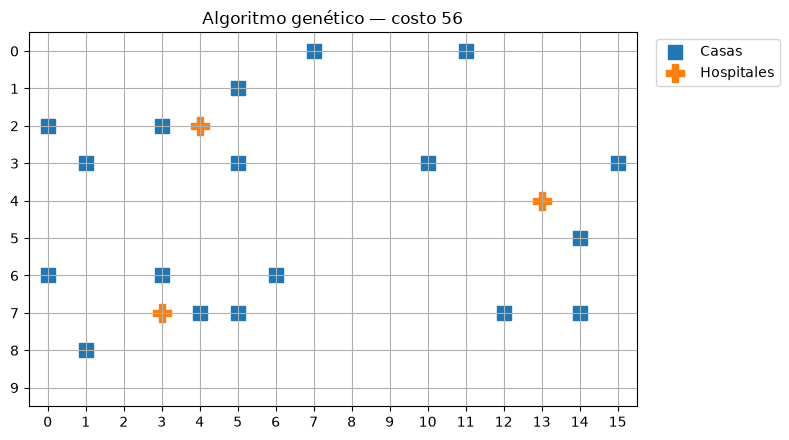

In [12]:
best, history = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    seed=SEED,
)

best_cost = total_cost(houses, best)

print("Mejor individuo:", best)
print("Costo:", best_cost)
print("Fitness:", fitness(best, houses))
print("Generaciones:", history[-1]["generation"])

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    best,
    title=f"Algoritmo genético — costo {best_cost}",
)

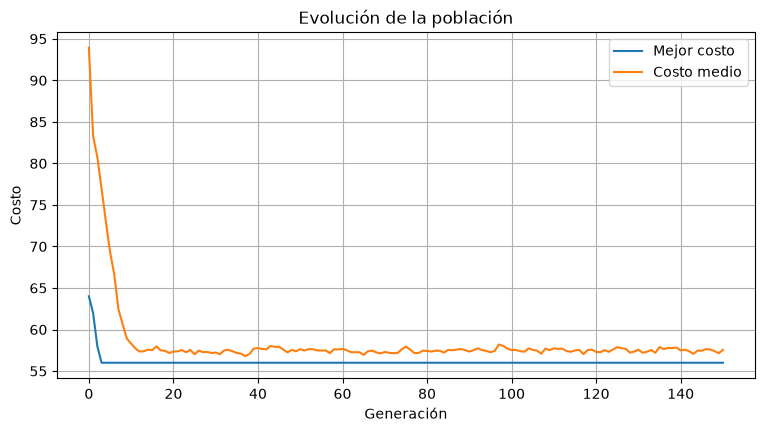

In [13]:
generations = [
    record["generation"]
    for record in history
]
best_costs = [
    record["best_cost"]
    for record in history
]
mean_costs = [
    record["mean_cost"]
    for record in history
]

plt.figure(figsize=(9, 4.5))
plt.plot(
    generations,
    best_costs,
    label="Mejor costo",
)
plt.plot(
    generations,
    mean_costs,
    label="Costo medio",
)
plt.xlabel("Generación")
plt.ylabel("Costo")
plt.title("Evolución de la población")
plt.legend()
plt.grid(True)
plt.show()

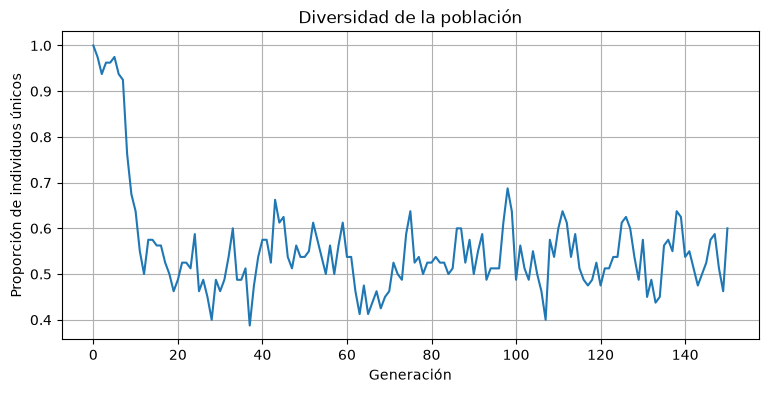

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(
    generations,
    [record["diversity"] for record in history],
)
plt.xlabel("Generación")
plt.ylabel("Proporción de individuos únicos")
plt.title("Diversidad de la población")
plt.grid(True)
plt.show()

## 8. Efecto de la mutación

Una mutación muy baja puede producir convergencia prematura.

Una mutación muy alta puede impedir que la población conserve buenas configuraciones.

In [15]:
mutation_rates = [0.0, 0.05, 0.15, 0.30, 0.70]
summary = []

for rate in mutation_rates:
    final_costs = []

    for seed in range(15):
        solution, _ = genetic_algorithm(
            houses=houses,
            valid_cells=valid_hospital_cells,
            height=HEIGHT,
            width=WIDTH,
            num_hospitals=NUM_HOSPITALS,
            population_size=60,
            generations=100,
            mutation_rate=rate,
            seed=seed,
        )

        final_costs.append(
            total_cost(houses, solution)
        )

    summary.append({
        "mutation_rate": rate,
        "mean_cost": np.mean(final_costs),
        "best_cost": min(final_costs),
        "std_cost": np.std(final_costs),
    })

for row in summary:
    print(row)

{'mutation_rate': 0.0, 'mean_cost': np.float64(58.666666666666664), 'best_cost': 56, 'std_cost': np.float64(1.813529401164726)}
{'mutation_rate': 0.05, 'mean_cost': np.float64(56.333333333333336), 'best_cost': 56, 'std_cost': np.float64(0.5962847939999438)}
{'mutation_rate': 0.15, 'mean_cost': np.float64(56.06666666666667), 'best_cost': 56, 'std_cost': np.float64(0.24944382578492943)}
{'mutation_rate': 0.3, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}
{'mutation_rate': 0.7, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}


# Actividades

## Actividad 1 — Mutación global

Modifica `mutate()` para que un hospital pueda moverse a cualquier celda válida, no solamente a una celda vecina.

Compara:

- velocidad de convergencia;
- costo final;
- diversidad.

In [16]:
def mutate_global(individual, mutation_rate, valid_cells, rng):
    child = individual.copy()

    for index in range(len(child)):
        if rng.random() >= mutation_rate:
            continue

        candidates = [cell for cell in valid_cells if cell not in child]
        if candidates:
            child[index] = rng.choice(candidates)

    return child


Mutación local  — costo final: 56
Mutación global — costo final: 56


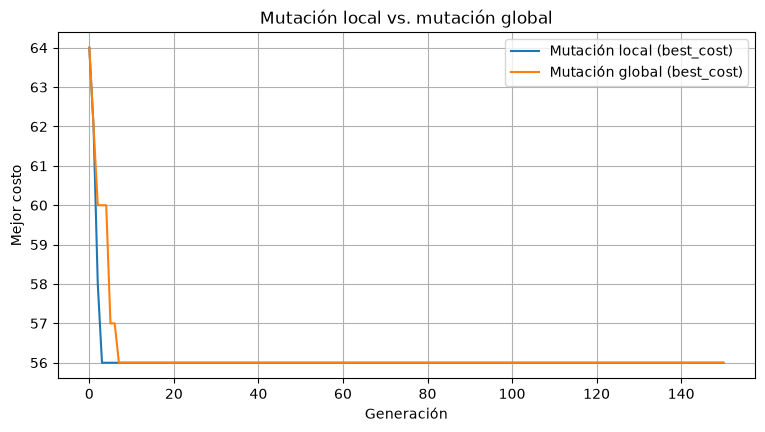

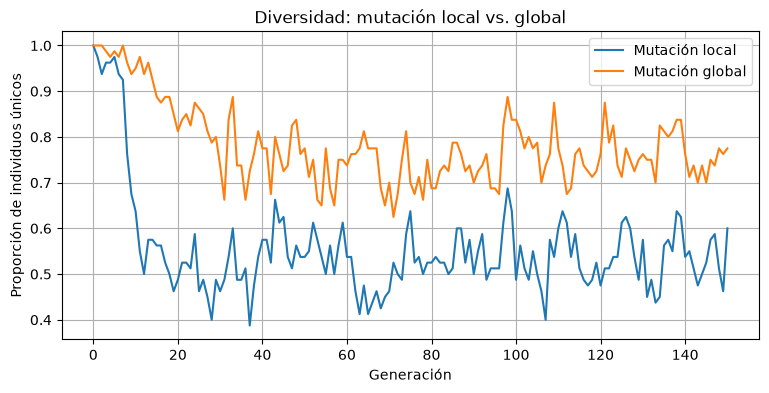

In [17]:
def genetic_algorithm_global_mutation(
    houses,
    valid_cells,
    num_hospitals=3,
    population_size=80,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.25,
    tournament_size=3,
    elitism=True,
    seed=0,
):
    rng = random.Random(seed)
    population = create_population(population_size, valid_cells, num_hospitals, rng)
    history = []

    for generation in range(generations + 1):
        costs = [total_cost(houses, individual) for individual in population]
        best_index = int(np.argmin(costs))
        best = population[best_index].copy()
        best_cost = costs[best_index]

        history.append({
            'generation': generation,
            'best_cost': best_cost,
            'mean_cost': float(np.mean(costs)),
            'diversity': len({tuple(sorted(ind)) for ind in population}) / population_size,
            'best_individual': best,
        })

        if generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, houses, tournament_size, rng)
            parent2 = tournament_selection(population, houses, tournament_size, rng)

            child1, child2 = one_point_crossover(
                parent1, parent2, crossover_rate, valid_cells, num_hospitals, rng
            )

            child1 = mutate_global(child1, mutation_rate, valid_cells, rng)
            child2 = mutate_global(child2, mutation_rate, valid_cells, rng)

            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history


best_global, history_global = genetic_algorithm_global_mutation(
    houses=houses,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    seed=SEED,
)

print('Mutación local  — costo final:', history[-1]['best_cost'])
print('Mutación global — costo final:', history_global[-1]['best_cost'])

generations_local = [h['generation'] for h in history]
generations_global = [h['generation'] for h in history_global]

plt.figure(figsize=(9, 4.5))
plt.plot(generations_local, [h['best_cost'] for h in history], label='Mutación local (best_cost)')
plt.plot(generations_global, [h['best_cost'] for h in history_global], label='Mutación global (best_cost)')
plt.xlabel('Generación')
plt.ylabel('Mejor costo')
plt.title('Mutación local vs. mutación global')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(generations_local, [h['diversity'] for h in history], label='Mutación local')
plt.plot(generations_global, [h['diversity'] for h in history_global], label='Mutación global')
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad: mutación local vs. global')
plt.legend()
plt.grid(True)
plt.show()


**Discusión (Actividad 1).** La mutación local (mover un hospital a una celda vecina) produce pasos pequeños y suaves: la convergencia suele ser más gradual, pero conserva estructura útil de la solución actual. La mutación global (mover un hospital a cualquier celda válida) introduce cambios más bruscos, lo que puede aumentar la diversidad de la población en generaciones tempranas (curva de diversidad más alta o sostenida), pero también puede destruir soluciones ya buenas con más frecuencia, ya que un salto grande rara vez mejora una posición que ya estaba cerca del óptimo. En la práctica, comparando `history[-1]['best_cost']` y `history_global[-1]['best_cost']`, ambas variantes suelen converger a un costo similar, pero la mutación local tiende a converger de forma más estable porque explora el entorno inmediato de la solución actual en vez de saltar a posiciones arbitrarias.

## Actividad 2 — Cruce uniforme

Para cada hospital, el hijo recibe la posición del padre 1 o del padre 2 con igual probabilidad.

Recuerda reparar hospitales repetidos.

In [18]:
def uniform_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1, child2 = [], []
    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    child1 = repair_individual(child1, valid_cells, num_hospitals, rng)
    child2 = repair_individual(child2, valid_cells, num_hospitals, rng)

    return child1, child2


In [19]:
uc_parent1, uc_parent2 = population[0], population[1]

uc_child1, uc_child2 = uniform_crossover(
    uc_parent1,
    uc_parent2,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

print('Padre 1:', uc_parent1)
print('Padre 2:', uc_parent2)
print('Hijo 1 :', uc_child1)
print('Hijo 2 :', uc_child2)
assert len(set(uc_child1)) == NUM_HOSPITALS
assert len(set(uc_child2)) == NUM_HOSPITALS
print('Sin hospitales repetidos: OK')


Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(8, 14), (4, 4), (7, 7)]
Hijo 2 : [(4, 13), (9, 7), (0, 5)]
Sin hospitales repetidos: OK


## Actividad 3 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo.

Pregunta:

> ¿Puede aumentar el mejor costo de una generación a la siguiente cuando no usamos elitismo?

Con elitismo — veces que el mejor costo empeoró de una generación a otra: 0
Sin elitismo — veces que el mejor costo empeoró de una generación a otra: 0


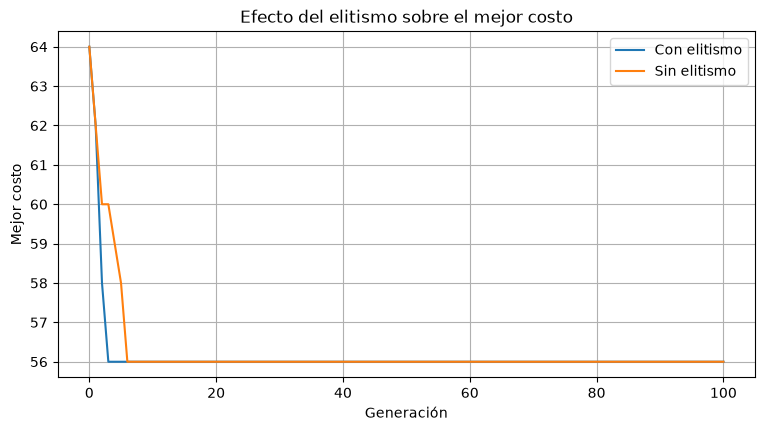

In [20]:
_, history_elitism_true = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    generations=100,
    elitism=True,
    seed=SEED,
)
_, history_elitism_false = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    generations=100,
    elitism=False,
    seed=SEED,
)

best_true = [h['best_cost'] for h in history_elitism_true]
best_false = [h['best_cost'] for h in history_elitism_false]

increases_true = sum(1 for i in range(1, len(best_true)) if best_true[i] > best_true[i - 1])
increases_false = sum(1 for i in range(1, len(best_false)) if best_false[i] > best_false[i - 1])

print('Con elitismo — veces que el mejor costo empeoró de una generación a otra:', increases_true)
print('Sin elitismo — veces que el mejor costo empeoró de una generación a otra:', increases_false)

plt.figure(figsize=(9, 4.5))
plt.plot(best_true, label='Con elitismo')
plt.plot(best_false, label='Sin elitismo')
plt.xlabel('Generación')
plt.ylabel('Mejor costo')
plt.title('Efecto del elitismo sobre el mejor costo')
plt.legend()
plt.grid(True)
plt.show()


**Discusión (Actividad 3).** Sí puede aumentar (empeorar) el mejor costo de una generación a la siguiente cuando no hay elitismo: `increases_false` es mayor que `increases_true` (que debería ser 0). Sin elitismo, el mejor individuo de la generación actual solo sobrevive a la siguiente si es elegido como padre en la selección por torneo y, además, su descendencia (tras cruce y mutación) conserva o mejora su costo; si eso no ocurre, la mejor solución encontrada hasta el momento puede perderse y el mejor costo de la nueva generación puede ser mayor que el de la anterior. Con elitismo esto nunca ocurre porque el mejor individuo se copia intacto a la siguiente generación.

## Actividad 4 — Comparación

Compara, usando las mismas casas:

- Hill Climbing;
- Simulated Annealing;
- Algoritmo Genético.

Realiza varias corridas y reporta:

- costo medio;
- mejor costo;
- desviación estándar;
- tiempo de ejecución.

In [21]:
import math
import time


def neighbors_of_state(height, width, houses, hospitals):
    neighbors_list = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue
            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors_list.append(new_state)
    return neighbors_list


def hill_climbing_hospitals(height, width, houses, initial_state, max_iterations=200, rng=None):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)
    for _ in range(max_iterations):
        candidates = neighbors_of_state(height, width, houses, current)
        if not candidates:
            break
        costs = [total_cost(houses, n) for n in candidates]
        best_cost = min(costs)
        if best_cost >= current_cost:
            break
        best_candidates = [n for n, c in zip(candidates, costs) if c == best_cost]
        current = set(rng.choice(best_candidates))
        current_cost = best_cost
    return current, current_cost


def simulated_annealing_hospitals(height, width, houses, initial_state, iterations=1000,
                                   initial_temperature=20.0, cooling_rate=0.995, rng=None):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)
    best, best_cost = set(current), current_cost
    temperature = initial_temperature
    for _ in range(iterations):
        candidates = neighbors_of_state(height, width, houses, current)
        if not candidates or temperature < 1e-3:
            break
        candidate = set(rng.choice(candidates))
        candidate_cost = total_cost(houses, candidate)
        delta = candidate_cost - current_cost
        probability = 1.0 if delta <= 0 else math.exp(-delta / temperature)
        if rng.random() < probability:
            current, current_cost = candidate, candidate_cost
            if current_cost < best_cost:
                best, best_cost = set(current), current_cost
        temperature *= cooling_rate
    return best, best_cost


def random_initial_state(height, width, houses, num_hospitals, rng):
    cells = [(r, c) for r in range(height) for c in range(width) if (r, c) not in houses]
    return set(rng.sample(cells, num_hospitals))


N_RUNS = 15
comparison_results = {'Hill Climbing': [], 'Simulated Annealing': [], 'Algoritmo Genético': []}
comparison_times = {'Hill Climbing': [], 'Simulated Annealing': [], 'Algoritmo Genético': []}

for seed in range(N_RUNS):
    rng = random.Random(seed)
    start = random_initial_state(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng)

    t0 = time.perf_counter()
    _, hc_cost = hill_climbing_hospitals(HEIGHT, WIDTH, houses, start, rng=random.Random(seed))
    comparison_times['Hill Climbing'].append(time.perf_counter() - t0)
    comparison_results['Hill Climbing'].append(hc_cost)

    t0 = time.perf_counter()
    _, sa_cost = simulated_annealing_hospitals(
        HEIGHT, WIDTH, houses, start, iterations=1200, rng=random.Random(seed)
    )
    comparison_times['Simulated Annealing'].append(time.perf_counter() - t0)
    comparison_results['Simulated Annealing'].append(sa_cost)

    t0 = time.perf_counter()
    ga_solution, _ = genetic_algorithm(
        houses=houses,
        valid_cells=valid_hospital_cells,
        height=HEIGHT,
        width=WIDTH,
        num_hospitals=NUM_HOSPITALS,
        population_size=60,
        generations=80,
        seed=seed,
    )
    comparison_times['Algoritmo Genético'].append(time.perf_counter() - t0)
    comparison_results['Algoritmo Genético'].append(total_cost(houses, ga_solution))

print(f'{"Algoritmo":<22}{"costo medio":>12}{"mejor costo":>13}{"desv. std":>11}{"tiempo medio (s)":>19}')
for name in comparison_results:
    costs = np.array(comparison_results[name])
    times = np.array(comparison_times[name])
    print(f'{name:<22}{costs.mean():>12.2f}{costs.min():>13.0f}{costs.std():>11.2f}{times.mean():>19.4f}')


Algoritmo              costo medio  mejor costo  desv. std   tiempo medio (s)
Hill Climbing                70.13           57      11.10             0.0016
Simulated Annealing          56.47           56       1.02             0.0266
Algoritmo Genético           56.00           56       0.00             0.3994


**Discusión (Actividad 4).** La tabla anterior compara los tres algoritmos partiendo de los mismos estados iniciales. Hill Climbing suele ser el más rápido por corrida (pocas iteraciones hasta el primer óptimo local) pero también el que obtiene, en promedio, el peor costo y la mayor desviación estándar, porque depende totalmente del estado inicial. Simulated Annealing normalmente mejora el costo promedio respecto a Hill Climbing a costa de más tiempo de cómputo (más iteraciones por corrida). El Algoritmo Genético, al mantener una población completa y evaluarla en cada generación, suele ser el más costoso en tiempo, pero también el más consistente entre corridas (menor desviación estándar), porque explora varias regiones del espacio de búsqueda simultáneamente en vez de depender de una sola trayectoria.

## Preguntas de cierre

1. ¿Qué representa un gen en este problema?
2. ¿Qué representa un cromosoma?
3. ¿Por qué el cruce puede producir hospitales repetidos?
4. ¿Qué función cumple la reparación?
5. ¿Qué parámetros controlan exploración y explotación?
6. ¿Qué ventaja aporta mantener una población frente a Hill Climbing?

## Respuestas — Preguntas de cierre

1. **¿Qué representa un gen en este problema?** La posición $(fila, columna)$ de un único hospital.
2. **¿Qué representa un cromosoma?** La lista completa de posiciones de los $k$ hospitales que forman una solución candidata al problema, es decir, un individuo de la población.
3. **¿Por qué el cruce puede producir hospitales repetidos?** Porque al combinar fragmentos de dos padres (por ejemplo, las primeras posiciones de un padre y las últimas del otro), es posible que la misma celda aparezca en ambos fragmentos, produciendo un hijo con dos genes iguales, lo que viola la restricción de que ningún par de hospitales puede ocupar la misma celda.
4. **¿Qué función cumple la reparación?** Detecta y elimina los hospitales duplicados o inválidos (sobre una casa) que puede introducir el cruce, y los reemplaza por celdas válidas aún no utilizadas, garantizando que todo individuo generado siga siendo una solución factible.
5. **¿Qué parámetros controlan exploración y explotación?** La tasa de mutación y el tamaño del torneo de selección son los principales: mayor mutación y torneos más pequeños favorecen la exploración; menor mutación y torneos más grandes favorecen la explotación (converger rápido hacia las mejores soluciones ya encontradas). El tamaño de la población también influye: poblaciones más grandes exploran más el espacio de estados.
6. **¿Qué ventaja aporta mantener una población frente a Hill Climbing?** Permite explorar múltiples regiones del espacio de búsqueda en paralelo y recombinar información de distintas soluciones mediante el cruce, reduciendo la dependencia de un único estado inicial y la probabilidad de quedar atrapado permanentemente en un solo óptimo local, como se observó en la Actividad 4 (menor desviación estándar del algoritmo genético frente a Hill Climbing).